# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


import warnings


from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score

from sklearn.model_selection import learning_curve


# Analysis and organization

In [2]:
# Carregar o arquivo
df = pd.read_csv('data/dados_quantum_walk_T_100_50.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.010686,16.109290,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.021371,17.274234,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.032057,17.394967,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.042743,21.982325,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


In [3]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,4.000856e-06,0.0,1.397188e-04,...,1.397188e-04,0.0,4.000856e-06,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,4.209793e-06,0.0,1.458290e-04,...,1.458290e-04,0.0,4.209793e-06,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,3.336867e-06,0.0,1.187927e-04,...,1.187927e-04,0.0,3.336867e-06,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,5.076300e-06,0.0,1.697867e-04,...,1.697867e-04,0.0,5.076300e-06,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,4.156066e-06,0.0,1.409257e-04,...,1.409257e-04,0.0,4.156066e-06,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0
5,0.0,5.365476e-13,0.0,5.196309e-10,0.0,1.032697e-07,0.0,7.293757e-06,0.0,2.236475e-04,...,2.236475e-04,0.0,7.293757e-06,0.0,1.032697e-07,0.0,5.196309e-10,0.0,5.365476e-13,0.0
6,0.0,7.931101e-13,0.0,7.456132e-10,0.0,1.433947e-07,0.0,9.758274e-06,0.0,2.864657e-04,...,2.864657e-04,0.0,9.758274e-06,0.0,1.433947e-07,0.0,7.456132e-10,0.0,7.931101e-13,0.0
7,0.0,6.617124e-14,0.0,7.502124e-11,0.0,1.761793e-08,0.0,1.488486e-06,0.0,5.552412e-05,...,5.552412e-05,0.0,1.488486e-06,0.0,1.761793e-08,0.0,7.502124e-11,0.0,6.617124e-14,0.0
8,0.0,2.735131e-14,0.0,3.330237e-11,0.0,8.428507e-09,0.0,7.708791e-07,0.0,3.131194e-05,...,3.131194e-05,0.0,7.708791e-07,0.0,8.428507e-09,0.0,3.330237e-11,0.0,2.735131e-14,0.0
9,0.0,2.142305e-13,0.0,2.241858e-10,0.0,4.822221e-08,0.0,3.695940e-06,0.0,1.235011e-04,...,1.235011e-04,0.0,3.695940e-06,0.0,4.822221e-08,0.0,2.241858e-10,0.0,2.142305e-13,0.0


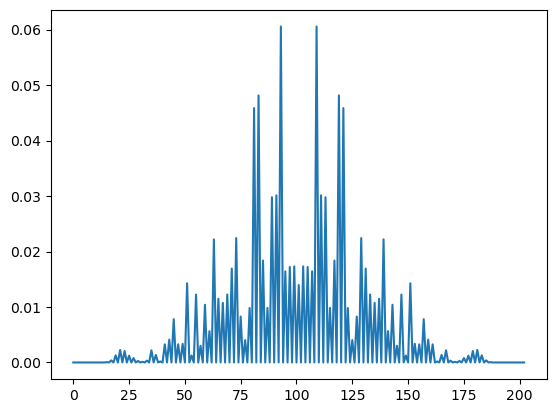

In [4]:
plt.plot(df_probs.iloc[25].values)
plt.show()

In [5]:
df_probs.iloc[0].values

array([0.00000000e+00, 2.13813479e-13, 0.00000000e+00, 2.28305281e-10,
       0.00000000e+00, 5.04342442e-08, 0.00000000e+00, 4.00085572e-06,
       0.00000000e+00, 1.39718777e-04, 0.00000000e+00, 2.33656618e-03,
       0.00000000e+00, 1.89575285e-02, 0.00000000e+00, 7.00815773e-02,
       0.00000000e+00, 9.47670208e-02, 0.00000000e+00, 1.82400804e-02,
       0.00000000e+00, 2.70930685e-02, 0.00000000e+00, 2.47151503e-02,
       0.00000000e+00, 1.64914838e-02, 0.00000000e+00, 1.36928518e-02,
       0.00000000e+00, 1.95235826e-02, 0.00000000e+00, 4.50719896e-03,
       0.00000000e+00, 1.68379788e-02, 0.00000000e+00, 9.65520384e-03,
       0.00000000e+00, 4.97749378e-03, 0.00000000e+00, 1.21070190e-02,
       0.00000000e+00, 9.29006015e-03, 0.00000000e+00, 4.16634559e-03,
       0.00000000e+00, 6.72210339e-03, 0.00000000e+00, 9.20466808e-03,
       0.00000000e+00, 6.75880094e-03, 0.00000000e+00, 4.13809334e-03,
       0.00000000e+00, 4.71332363e-03, 0.00000000e+00, 6.42320676e-03,
      

In [6]:
len(df_probs)

50

List of IPR

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


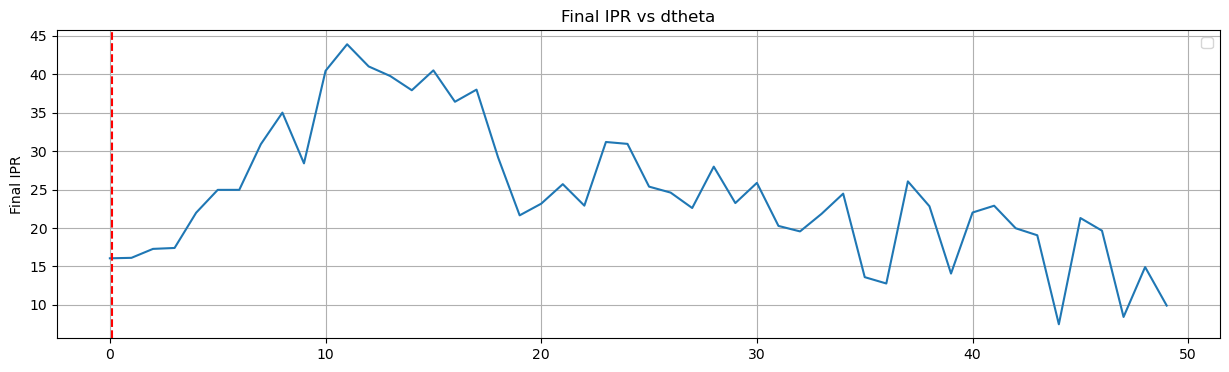

In [7]:
IPR_list = df['IPR'].values

plt.figure(figsize=(15,4))
plt.plot(df['IPR'].values)
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
#plt.xlim(0, 7500)
plt.legend()
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


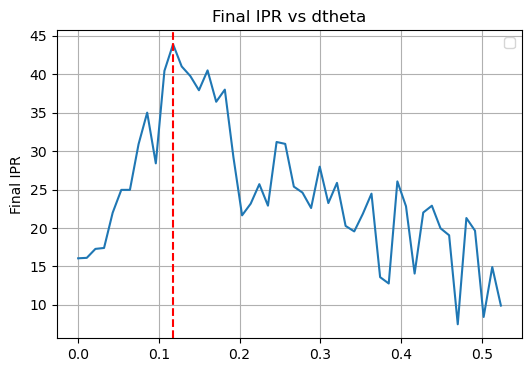

In [8]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

0.1175425822771691

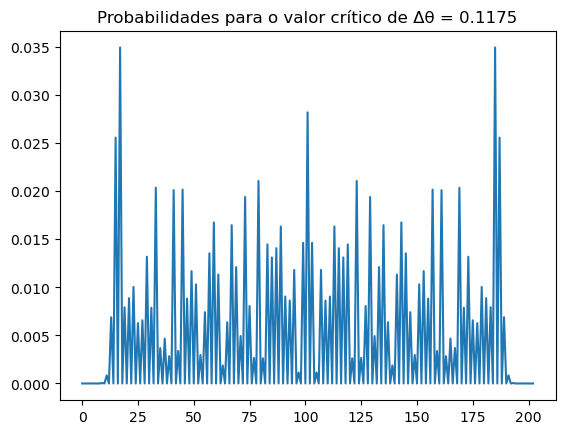

In [10]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [11]:
# Assigning labels to the training data

n_total = len(df)
ponto_de_corte = np.argmax(df['IPR'].values)  # Onde os 0s terminam e os 1s começam

# Cria a coluna: metade 0, metade 1
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# Adiciona a coluna ao DataFrame e garanto que seja inteira
df_probs['label'] = coluna_rotulo.astype(int)

/tmp/ipykernel_19719/2789398605.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probs['label'] = coluna_rotulo.astype(int)


Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [12]:
df_training = df_probs.iloc[np.r_[0:8, 42:50]]

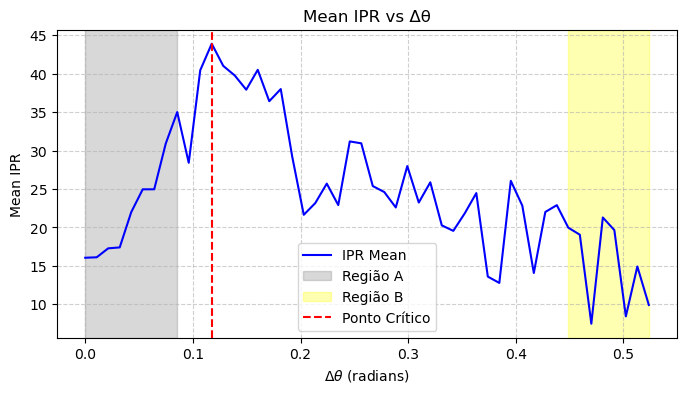

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values,df['IPR'].values, label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:][0], df['delta_theta'].values[:][8], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:][42], df['delta_theta'].values[:][49], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

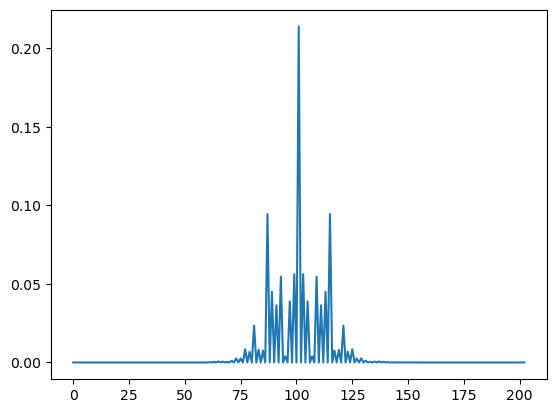

In [14]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [15]:
len(df_probs.iloc[49].values)

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [16]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

In [17]:
df_train.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202,label
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,4.000856e-06,0.0,1.397188e-04,...,0.0,4.000856e-06,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0,0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,4.209793e-06,0.0,1.458290e-04,...,0.0,4.209793e-06,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0,0
5,0.0,5.365476e-13,0.0,5.196309e-10,0.0,1.032697e-07,0.0,7.293757e-06,0.0,2.236475e-04,...,0.0,7.293757e-06,0.0,1.032697e-07,0.0,5.196309e-10,0.0,5.365476e-13,0.0,0
48,0.0,4.257465e-32,0.0,2.594491e-28,0.0,3.219640e-25,0.0,1.413168e-22,0.0,2.689253e-20,...,0.0,1.413168e-22,0.0,3.219640e-25,0.0,2.594491e-28,0.0,4.257465e-32,0.0,1
47,0.0,3.842752e-30,0.0,1.734951e-26,0.0,1.615047e-23,0.0,5.402049e-21,0.0,8.005230e-19,...,0.0,5.402049e-21,0.0,1.615047e-23,0.0,1.734951e-26,0.0,3.842752e-30,0.0,1


In [18]:
df_train.head().values[0][:-1]

array([0.00000000e+00, 2.13813479e-13, 0.00000000e+00, 2.28305281e-10,
       0.00000000e+00, 5.04342442e-08, 0.00000000e+00, 4.00085572e-06,
       0.00000000e+00, 1.39718777e-04, 0.00000000e+00, 2.33656618e-03,
       0.00000000e+00, 1.89575285e-02, 0.00000000e+00, 7.00815773e-02,
       0.00000000e+00, 9.47670208e-02, 0.00000000e+00, 1.82400804e-02,
       0.00000000e+00, 2.70930685e-02, 0.00000000e+00, 2.47151503e-02,
       0.00000000e+00, 1.64914838e-02, 0.00000000e+00, 1.36928518e-02,
       0.00000000e+00, 1.95235826e-02, 0.00000000e+00, 4.50719896e-03,
       0.00000000e+00, 1.68379788e-02, 0.00000000e+00, 9.65520384e-03,
       0.00000000e+00, 4.97749378e-03, 0.00000000e+00, 1.21070190e-02,
       0.00000000e+00, 9.29006015e-03, 0.00000000e+00, 4.16634559e-03,
       0.00000000e+00, 6.72210339e-03, 0.00000000e+00, 9.20466808e-03,
       0.00000000e+00, 6.75880094e-03, 0.00000000e+00, 4.13809334e-03,
       0.00000000e+00, 4.71332363e-03, 0.00000000e+00, 6.42320676e-03,
      

# few samples

In [27]:
# O 'loss=modified_huber' é o segredo para ter probabilidades no SVM
clf = SGDClassifier(loss='modified_huber', penalty='l2', alpha=0.0001,max_iter=1000000, tol=0.00001,learning_rate='optimal',early_stopping=True,n_iter_no_change=10000)

# Divida seus dados (80% treino, 20% teste)
# X são as distribuições de probabilidade, y são os rótulos 0 e 1
X_train = df_train.drop(columns=['label']).values
y_train = df_train['label'].values
clf.fit(X_train, y_train)

SGDClassifier(early_stopping=True, loss='modified_huber', max_iter=1000000,
              n_iter_no_change=10000, tol=1e-05)

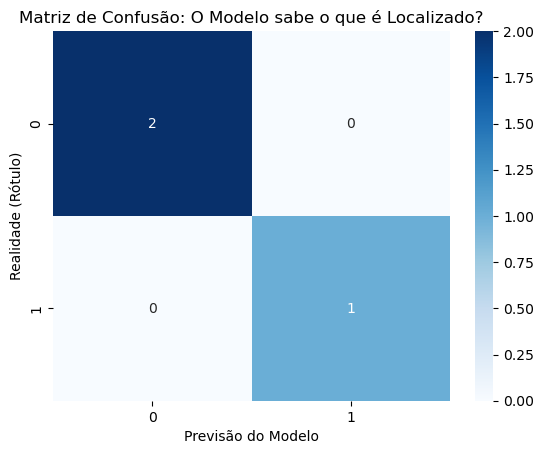

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [28]:
# 1. Fazer previsões nos dados de teste (os 20% reservados)

X_test = df_test.drop(columns=['label']).values
y_test = df_test['label'].values
y_pred = clf.predict(X_test)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar visualmente
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Rótulo)')
plt.title('Matriz de Confusão: O Modelo sabe o que é Localizado?')
plt.show()

print(classification_report(y_test, y_pred))

Predicting the result

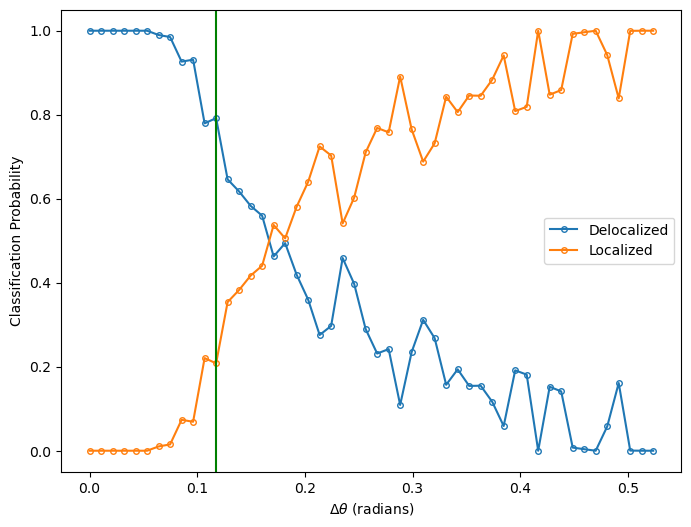

In [29]:
# Usaremos todos os dados para prever o ponto crítico
probs = clf.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])

# valores de theta para plotar
delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
# Supondo que 'delta_thetas' seja a lista de valores que você usou na transição
prob_delocalized = probs[:, 0]
prob_localized = probs[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(delta_theta_trans, prob_delocalized, '-o', label='Delocalized', markersize=4, markerfacecolor='none')
plt.plot(delta_theta_trans, prob_localized, '-o', label='Localized', markersize=4, markerfacecolor='none')

# Linha vertical no ponto de cruzamento (ajuste o 0.2 para o seu resultado)
plt.axvline(x=critical_exp, color='green', linestyle='-') 
#plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Classification Probability')
plt.legend()
plt.show()

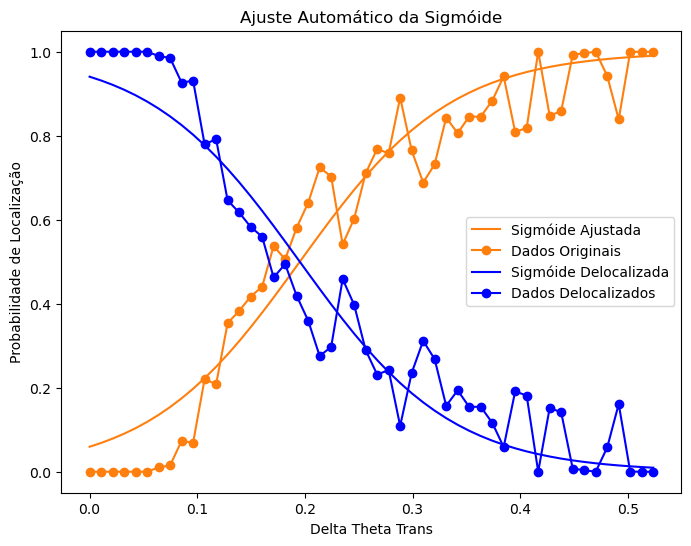

In [30]:
def sigmoide_automatica(x, y):
    # --- AUTO-CHUTE (O segredo para não falhar) ---
    # Centro (x0): Onde o y está mais próximo de 0.5
    x0_chute = x[np.argmin(np.abs(y - 0.5))]
    
    # Inclinação (k): Estimada pela diferença entre os extremos
    # Se a curva sobe, k é positivo. Se desce, k é negativo.
    k_chute = (y[-1] - y[0]) / (x[-1] - x[0]) * 4 

    # Função modelo: Sigmóide padrão
    def f(x, k, x0):
        return 1 / (1 + np.exp(-k * (x - x0)))

    # Ajuste com os chutes calculados automaticamente
    popt, pcov = curve_fit(f, x, y, p0=[k_chute, x0_chute])
    
    return popt # Retorna [k, x0]

# Aplicar a função de ajuste automático
k_ajustado, x0_ajustado = sigmoide_automatica(delta_theta_trans, prob_localized)
prob_localized_ajustada = 1 / (1 + np.exp(-k_ajustado * (delta_theta_trans - x0_ajustado)))

k_ajustado_delocalized = -k_ajustado
x0_ajustado_delocalized = x0_ajustado
prob_delocalized_ajustada = 1 / (1 + np.exp(-k_ajustado_delocalized * (delta_theta_trans - x0_ajustado_delocalized)))
plt.figure(figsize=(8, 6))
plt.plot(delta_theta_trans, prob_localized_ajustada, '-', color='tab:orange', label='Sigmóide Ajustada')
plt.plot(delta_theta_trans, prob_localized, '-o', color='tab:orange', label='Dados Originais')
plt.plot(delta_theta_trans, prob_delocalized_ajustada, '-', color='blue', label='Sigmóide Delocalizada')
plt.plot(delta_theta_trans, prob_delocalized, '-o', color='blue', label='Dados Delocalizados')
plt.xlabel('Delta Theta Trans')
plt.ylabel('Probabilidade de Localização')
plt.title('Ajuste Automático da Sigmóide')
plt.legend()
plt.show()

In [31]:
x0_ajustado,sigmoide_automatica(delta_theta_trans, prob_localized)[1]

(0.19528922385662983, 0.19528922385662983)

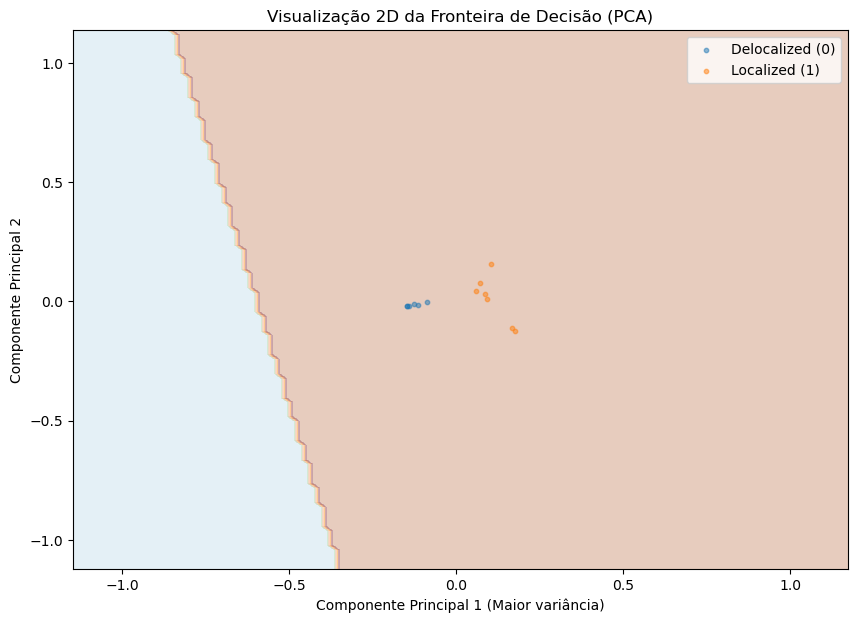

In [ ]:
"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Normalizar e Reduzir para 2D
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_train) # Suas 2500 linhas x 200 colunas

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# 2. Treinar um SVM simples no espaço 2D para visualização
from sklearn.svm import SVC
modelo_vis = SVC(kernel='linear', C=1.0)
modelo_vis.fit(X_pca, y_train)

# 3. Criar a malha para desenhar a curva (Decision Boundary)
h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = modelo_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotar
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3) # Área de decisão
plt.scatter(X_pca[y_train==0, 0], X_pca[y_train==0, 1], label='Delocalized (0)', alpha=0.5, s=10)
plt.scatter(X_pca[y_train==1, 0], X_pca[y_train==1, 1], label='Localized (1)', alpha=0.5, s=10)

plt.title("Visualização 2D da Fronteira de Decisão (PCA)")
plt.xlabel("Componente Principal 1 (Maior variância)")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.show()
"""

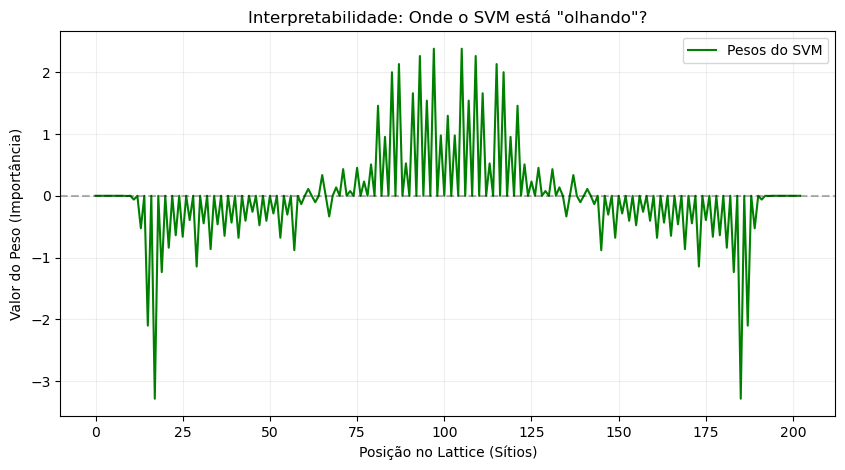

In [33]:
# O coef_ contém a importância de cada ponto do seu lattice
pesos = clf.coef_[0]

# Criar um eixo X representando as posições no lattice (ajuste o range conforme seu dado)
lattice_positions = np.arange(len(pesos))

plt.figure(figsize=(10, 5))
plt.plot(lattice_positions, pesos, color='green', label='Pesos do SVM')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.title('Interpretabilidade: Onde o SVM está "olhando"?')
plt.xlabel('Posição no Lattice (Sítios)')
plt.ylabel('Valor do Peso (Importância)')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# 600 samples

In [2]:
# Carregar o arquivo
df2 = pd.read_csv('/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/data/dados_quantum_walk_T_100_data_2500_2.csv')
df_probs2 = df2.filter(like='prob_')
IPR_list2 = df2['IPR'].values
df2.iloc[np.argmax(IPR_list2)]
critical_exp2 = df2['delta_theta'].iloc[np.argmax(IPR_list2)]
critical_exp2

0.120266385431542

In [3]:
# --- Configurações de Limites ---
limite2 = 2500
tamanho_total2 = 250000
tamanho_bloco2 = 2500

# --- Processamento do Bloco Inicial ---
# n_total será 2500
n_total2 = len(df2.iloc[:limite2])

# Localiza o ponto de transição dentro das primeiras 2500 linhas
ponto_de_corte2 = np.argmax(df2['IPR'].values[:limite2])

# Cria o bloco base: parte 0, parte 1 (Isso já gera um array NumPy)
coluna_rotulo2 = np.concatenate([
    np.zeros(ponto_de_corte2), 
    np.ones(n_total2 - ponto_de_corte2)
])

# --- Repetição para as 250.000 linhas ---
repeticoes2 = tamanho_total2 // tamanho_bloco2

# CORREÇÃO AQUI: Removido o .values, pois coluna_rotulo já é um array
labels_repetidos2 = np.tile(coluna_rotulo2, repeticoes2)

# Se o seu df_probs tiver um tamanho exato de 250.000, isso funcionará:
df_probs2['label'] = labels_repetidos2.astype(int)

/tmp/ipykernel_14122/1424354503.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probs2['label'] = labels_repetidos2.astype(int)


In [4]:
df_training2 = df_probs2.iloc[np.r_[0:300, -300:-1]]

# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train2 = df_training2.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test2 = df_training2.drop(df_train2.index)

In [10]:
clf2 = SGDClassifier(
            loss='modified_huber', 
            penalty='l2', 
            alpha=0.00001,
            max_iter=50000, 
            tol=1e-5, 
            learning_rate='optimal',
            early_stopping=True,
            n_iter_no_change=10000
            
        )

X_train2 = df_train2.drop(columns=['label']).values
y_train2 = df_train2['label'].values
clf2.fit(X_train2, y_train2)

SGDClassifier(alpha=1e-05, early_stopping=True, loss='modified_huber',
              max_iter=50000, n_iter_no_change=10000, tol=1e-05)

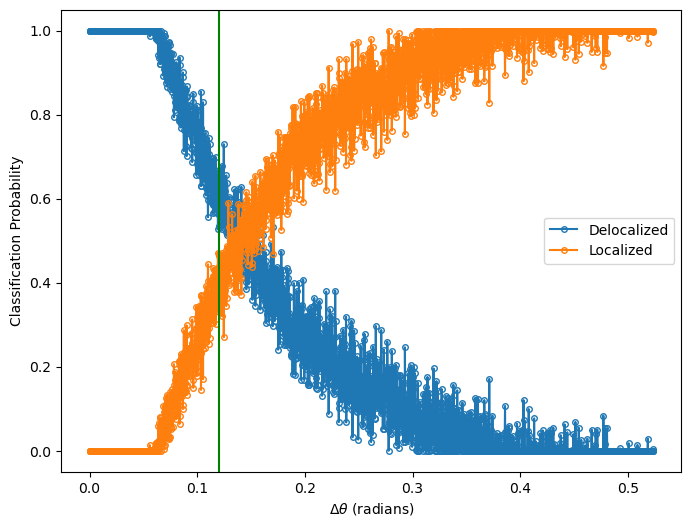

In [11]:
# Usaremos todos os dados para prever o ponto crítico
probs2 = clf2.predict_proba(df_probs2.drop(columns=['label']).values[:2500, :])

# valores de theta para plotar
delta_theta_trans2 = df2.filter(like='delta_theta').iloc[:2500].values.flatten()
# Supondo que 'delta_thetas' seja a lista de valores que você usou na transição
prob_delocalized2 = probs2[:, 0]
prob_localized2 = probs2[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(delta_theta_trans2, prob_delocalized2, '-o', label='Delocalized', markersize=4, markerfacecolor='none')
plt.plot(delta_theta_trans2, prob_localized2, '-o', label='Localized', markersize=4, markerfacecolor='none')

# Linha vertical no ponto de cruzamento (ajuste o 0.2 para o seu resultado)
plt.axvline(x=critical_exp2, color='green', linestyle='-') 
#plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Classification Probability')
plt.legend()
plt.show()

# Saving model

In [34]:
# Definir o nome do arquivo
#filename = 'modelo_svm_qw_final.joblib'

# Salvar o modelo e também o scaler (se você usou um)
#joblib.dump(clf3, f'data/{filename}')

# Se você usou normalização, SALVE o scaler também! 
# Você precisará dele para tratar os dados novos do mesmo jeito
# joblib.dump(scaler, 'scaler_qw.joblib')

#print(f"Modelo salvo com sucesso em: {filename}")